# Punktweises LSTM für Freiwerfklassifikation — PINN‑vergleichbare Variante

**Ziel:** Faire Vergleichbarkeit zum PINN.

- **Input (pro Datenpunkt):** `[theta, v0, hs, t]`
- **Output:** Klassenlabel pro Punkt (`0 = kurz`, `1 = Treffer`, `2 = lang`)
- **Datensätze:** clean & noisy
- **Auswertung:** Konfusionsmatrix, Accuracy/Precision/Recall/F1, ROC‑AUC (OvO), Calibration (Klasse=1), Sensitivity‑Heatmap `P(hit)` über `(theta, v0)`

Das Modell ist ein **LSTM**, das mit Sequenzlänge `1` arbeitet (punktweise). Dadurch ist die Eingabe identisch zum PINN‑Setup und die Ergebnisse direkt vergleichbar.

In [1]:
import os, sys, time, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.calibration import calibration_curve
print('Python', sys.version)
print('Torch', torch.__version__)


Python 3.13.5 (tags/v3.13.5:6cb20a2, Jun 11 2025, 16:15:46) [MSC v.1943 64 bit (AMD64)]
Torch 2.6.0+cpu


In [2]:
import importlib.util
dg_path = '/mnt/data/data_gen.py'
if os.path.exists(dg_path):
    spec = importlib.util.spec_from_file_location('data_gen', dg_path)
    data_gen = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(data_gen)
    DataGen = data_gen.DataGen
    print('Loaded DataGen from', dg_path)
else:
    print('WARNING: data_gen.py not found; defining fallback DataGen')
    class DataGen:
        def __init__(self, hs=2.13, l=4.115, hKorb=3.048, Rr=0.2286, Rb=0.1219, g=9.807):
            self.params = {'l': l, 'hKorb': hKorb, 'Rr': Rr, 'Rb': Rb, 'g': g}
            self.hs = hs
            self.wurf_hoehe = 1.25*hs
        def wurfgeschwindigkeit(self, theta):
            l = self.params['l']; h = self.params['hKorb'] - self.wurf_hoehe; g = self.params['g']
            return (l/np.cos(theta))*np.sqrt(g/(2*(l*np.tan(theta) - h)))
        def wurftrajektorien(self, theta, v0, t):
            g = self.params['g']; vx = v0*np.cos(theta); vy = v0*np.sin(theta)
            x = vx*t; y = vy*t - 0.5*g*t**2 + self.wurf_hoehe
            return x, y
        def generate_dataset(self, base_theta_deg=48.43, n=100, with_noise=False):
            base_theta = np.deg2rad(base_theta_deg); base_v0 = self.wurfgeschwindigkeit(base_theta)
            cats = {0:{'theta':(-0.15,-0.05),'v0':(-0.5,-0.2)}, 1:{'theta':(-0.03,0.03),'v0':(-0.1,0.1)}, 2:{'theta':(0.06,0.15),'v0':(0.3,0.5)}}
            all_rows=[]
            for label,var in cats.items():
                all_rows += self._gen(base_theta, base_v0, var, label, n)
            df = pd.DataFrame(all_rows)
            if with_noise: df = self.full_noise_pipeline(df)
            return df
        def _gen(self, theta_base, v0_base, var, label, n):
            g = self.params['g']; rows=[]
            for _ in range(n):
                theta = theta_base + np.random.uniform(*var['theta'])
                v0 = v0_base + np.random.uniform(*var['v0'])
                T = 2*v0*np.sin(theta)/g; t = np.linspace(0, T, 50)
                x,y = self.wurftrajektorien(theta, v0, t)
                wid = str(np.random.randint(1e9))
                for xi,yi,ti in zip(x,y,t):
                    rows.append({'x':xi,'y':yi,'theta':theta,'v0':v0,'t':ti,'label':label,'wurf_id':wid})
            return rows
        def add_position_noise(self, df, std_x=0.1, std_y=0.1):
            d = df.copy(); d['x'] += np.random.normal(0,std_x,len(df)); d['y'] += np.random.normal(0,std_y,len(df)); return d
        def add_initial_param_noise(self, df, std_theta=0.5, std_v0=0.5):
            d = df.copy(); d['theta'] += np.random.normal(0,std_theta,len(df)); d['v0'] += np.random.normal(0,std_v0,len(df)); return d
        def full_noise_pipeline(self, df):
            return self.add_initial_param_noise(self.add_position_noise(df))


In [3]:
def df_to_pointwise_tensors(df, hs_val=2.13, device='cpu'):
    d = df.copy()
    # ensure t is present; if not, reconstruct from x and vx
    if 't' not in d.columns:
        d['vx'] = d['v0']*np.cos(d['theta'])
        d['vx'] = d['vx'].replace(0, 1e-8)
        d['t'] = d['x']/d['vx']
    d['t'] = d['t'].clip(lower=0.0)
    d['hs'] = hs_val
    d = d.dropna(subset=['theta','v0','t','label'])
    X = d[['theta','v0','hs','t']].values.astype(np.float32)
    y = d['label'].astype(int).values
    # LSTM expects shape (N, seq_len, feat); we use seq_len=1
    X_seq = X.reshape(-1, 1, 4)
    Xt = torch.tensor(X_seq, dtype=torch.float32, device=device)
    yt = torch.tensor(y, dtype=torch.long, device=device)
    return Xt, yt, d


In [4]:
class PointLSTM(nn.Module):
    def __init__(self, input_size=4, hidden_size=64, num_layers=1, num_classes=3):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)
    def forward(self, x):
        out, _ = self.lstm(x)  # x: (N,1,4)
        out = out[:, -1, :]
        return self.fc(out)


In [5]:
def train_pointwise(model, loader, optim, crit, device):
    model.train(); tloss=0; tcorrect=0; ttotal=0
    for X,y in loader:
        X,y = X.to(device), y.to(device)
        optim.zero_grad(); logits = model(X); loss = crit(logits, y)
        loss.backward(); optim.step()
        tloss += loss.item()*X.size(0)
        preds = torch.argmax(logits, dim=1)
        tcorrect += (preds==y).sum().item(); ttotal += y.size(0)
    return tloss/ttotal, tcorrect/ttotal

def eval_pointwise(model, loader, crit, device):
    model.eval(); tloss=0; tcorrect=0; ttotal=0; all_probs=[]; all_y=[]; all_pred=[]
    with torch.no_grad():
        for X,y in loader:
            X,y = X.to(device), y.to(device)
            logits = model(X); loss = crit(logits, y)
            tloss += loss.item()*X.size(0)
            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)
            tcorrect += (preds==y).sum().item(); ttotal += y.size(0)
            all_probs.append(probs.cpu().numpy()); all_y.append(y.cpu().numpy()); all_pred.append(preds.cpu().numpy())
    probs = np.concatenate(all_probs); y_true = np.concatenate(all_y); y_pred = np.concatenate(all_pred)
    return tloss/ttotal, tcorrect/ttotal, probs, y_true, y_pred


## Training auf **clean** Punktdaten (≈ 22 500 Punkte)

In [6]:
device = torch.device('cpu')
sim = DataGen(hs=2.13)
df_clean = sim.generate_dataset(n=150, with_noise=False)
Xt, yt, dproc = df_to_pointwise_tensors(df_clean, hs_val=2.13, device='cpu')
dataset = TensorDataset(Xt, yt)
n = len(dataset); idx = np.random.permutation(n)
train_end = int(0.8*n); val_end = int(0.9*n)
train_idx, val_idx, test_idx = idx[:train_end], idx[train_end:val_end], idx[val_end:]
train_loader = DataLoader(torch.utils.data.Subset(dataset, train_idx), batch_size=512, shuffle=True)
val_loader = DataLoader(torch.utils.data.Subset(dataset, val_idx), batch_size=512, shuffle=False)
test_loader = DataLoader(torch.utils.data.Subset(dataset, test_idx), batch_size=512, shuffle=False)

model = PointLSTM(input_size=4, hidden_size=64, num_layers=1, num_classes=3).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
hist = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}
for ep in range(15):
    tr_loss, tr_acc = train_pointwise(model, train_loader, optimizer, criterion, device)
    va_loss, va_acc, _, _, _ = eval_pointwise(model, val_loader, criterion, device)
    hist['train_loss'].append(tr_loss); hist['train_acc'].append(tr_acc)
    hist['val_loss'].append(va_loss); hist['val_acc'].append(va_acc)
    if (ep+1)%5==0 or ep<3:
        print(f'Epoch {ep+1:02d} | train_loss={tr_loss:.4f}, train_acc={tr_acc:.3f} | val_loss={va_loss:.4f}, val_acc={va_acc:.3f}')


Epoch 01 | train_loss=1.0963, train_acc=0.350 | val_loss=1.0881, val_acc=0.347
Epoch 02 | train_loss=1.0822, train_acc=0.427 | val_loss=1.0716, val_acc=0.636
Epoch 03 | train_loss=1.0587, train_acc=0.542 | val_loss=1.0349, val_acc=0.613
Epoch 05 | train_loss=0.9365, train_acc=0.646 | val_loss=0.8852, val_acc=0.702
Epoch 10 | train_loss=0.5476, train_acc=0.991 | val_loss=0.5097, val_acc=0.994
Epoch 15 | train_loss=0.3488, train_acc=1.000 | val_loss=0.3236, val_acc=1.000


Text(0.5, 1.0, 'Lossverlauf (clean, pointwise)')

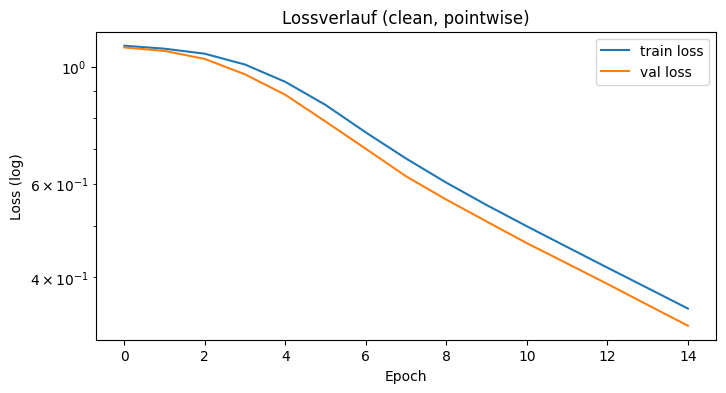

In [7]:
plt.figure(figsize=(8,4))
plt.plot(hist['train_loss'], label='train loss')
plt.plot(hist['val_loss'], label='val loss')
plt.yscale('log'); plt.xlabel('Epoch'); plt.ylabel('Loss (log)'); plt.legend(); plt.title('Lossverlauf (clean, pointwise)')


Test (clean): loss= 0.33415240557988485  acc= 1.0
Confusion matrix (clean):
 [[751   0   0]
 [  0 761   0]
 [  0   0 738]]


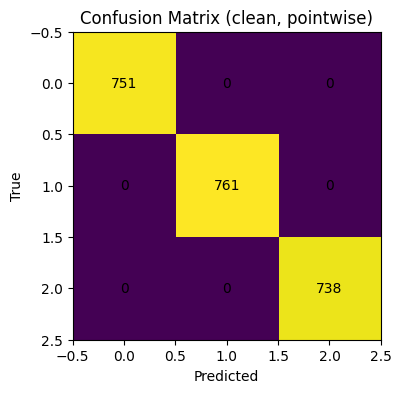

In [8]:
te_loss, te_acc, te_probs, te_true, te_pred = eval_pointwise(model, test_loader, criterion, device)
print('Test (clean): loss=', te_loss, ' acc=', te_acc)
cm = confusion_matrix(te_true, te_pred)
print('Confusion matrix (clean):\n', cm)
plt.figure(figsize=(5,4))
plt.imshow(cm)
plt.title('Confusion Matrix (clean, pointwise)')
plt.xlabel('Predicted'); plt.ylabel('True')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i,j], ha='center', va='center')


In [9]:
acc = accuracy_score(te_true, te_pred)
prec = precision_score(te_true, te_pred, average='macro', zero_division=0)
rec = recall_score(te_true, te_pred, average='macro', zero_division=0)
f1 = f1_score(te_true, te_pred, average='macro', zero_division=0)
print(f'Accuracy={acc:.3f} | Precision={prec:.3f} | Recall={rec:.3f} | F1={f1:.3f}')


Accuracy=1.000 | Precision=1.000 | Recall=1.000 | F1=1.000


ROC-AUC (macro, OvO): 1.0


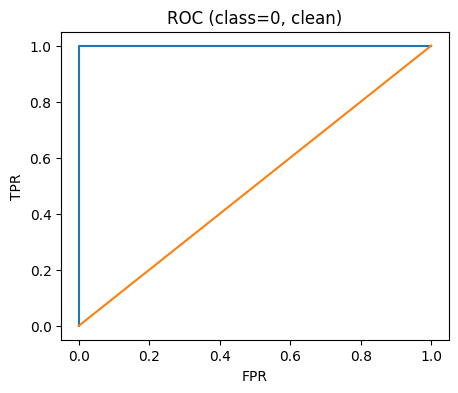

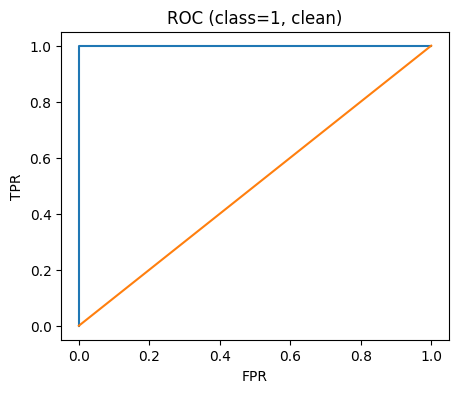

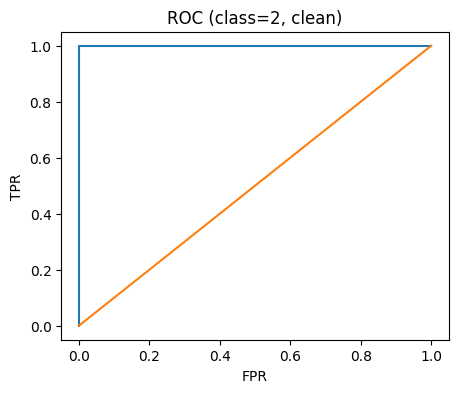

In [10]:
try:
    y_true_ovr = np.eye(3)[te_true]
    roc_auc = roc_auc_score(y_true_ovr, te_probs, average='macro', multi_class='ovo')
    print('ROC-AUC (macro, OvO):', roc_auc)
    for k in range(3):
        fpr, tpr, _ = roc_curve((te_true==k).astype(int), te_probs[:,k])
        plt.figure(figsize=(5,4))
        plt.plot(fpr, tpr)
        plt.plot([0,1],[0,1])
        plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title(f'ROC (class={k}, clean)')
except Exception as e:
    print('ROC computation failed:', e)


Text(0.5, 1.0, 'Calibration (clean, class=1)')

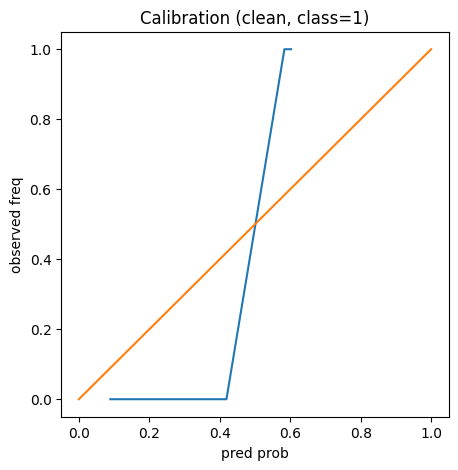

In [11]:
prob_true, prob_pred = calibration_curve((te_true==1).astype(int), te_probs[:,1], n_bins=10)
plt.figure(figsize=(5,5))
plt.plot(prob_pred, prob_true)
plt.plot([0,1],[0,1])
plt.xlabel('pred prob'); plt.ylabel('observed freq'); plt.title('Calibration (clean, class=1)')


## Training auf **noisy** Punktdaten und Vergleich

In [12]:
df_noisy = sim.generate_dataset(n=150, with_noise=True)
Xtn, ytn, dproc_n = df_to_pointwise_tensors(df_noisy, hs_val=2.13, device='cpu')
dataset_n = TensorDataset(Xtn, ytn)
n2 = len(dataset_n); idx2 = np.random.permutation(n2)
train_end2 = int(0.8*n2); val_end2 = int(0.9*n2)
train_idx2, val_idx2, test_idx2 = idx2[:train_end2], idx2[train_end2:val_end2], idx2[val_end2:]
train_loader_n = DataLoader(torch.utils.data.Subset(dataset_n, train_idx2), batch_size=512, shuffle=True)
val_loader_n = DataLoader(torch.utils.data.Subset(dataset_n, val_idx2), batch_size=512, shuffle=False)
test_loader_n = DataLoader(torch.utils.data.Subset(dataset_n, test_idx2), batch_size=512, shuffle=False)

model_n = PointLSTM(input_size=4, hidden_size=64, num_layers=1, num_classes=3).to(device)
opt_n = torch.optim.Adam(model_n.parameters(), lr=1e-3)
crit_n = nn.CrossEntropyLoss()
hist_n = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}
for ep in range(15):
    tr_loss, tr_acc = train_pointwise(model_n, train_loader_n, opt_n, crit_n, device)
    va_loss, va_acc, _, _, _ = eval_pointwise(model_n, val_loader_n, crit_n, device)
    hist_n['train_loss'].append(tr_loss); hist_n['train_acc'].append(tr_acc)
    hist_n['val_loss'].append(va_loss); hist_n['val_acc'].append(va_acc)
    if (ep+1)%5==0 or ep<3:
        print(f'[noisy] Epoch {ep+1:02d} | train_loss={tr_loss:.4f}, train_acc={tr_acc:.3f} | val_loss={va_loss:.4f}, val_acc={va_acc:.3f}')


[noisy] Epoch 01 | train_loss=1.0936, train_acc=0.374 | val_loss=1.0871, val_acc=0.447
[noisy] Epoch 02 | train_loss=1.0796, train_acc=0.449 | val_loss=1.0676, val_acc=0.488
[noisy] Epoch 03 | train_loss=1.0551, train_acc=0.469 | val_loss=1.0392, val_acc=0.499
[noisy] Epoch 05 | train_loss=0.9954, train_acc=0.506 | val_loss=0.9845, val_acc=0.523
[noisy] Epoch 10 | train_loss=0.9255, train_acc=0.543 | val_loss=0.9311, val_acc=0.543
[noisy] Epoch 15 | train_loss=0.9196, train_acc=0.543 | val_loss=0.9282, val_acc=0.538


Text(0.5, 1.0, 'Val-Loss: clean vs noisy (pointwise)')

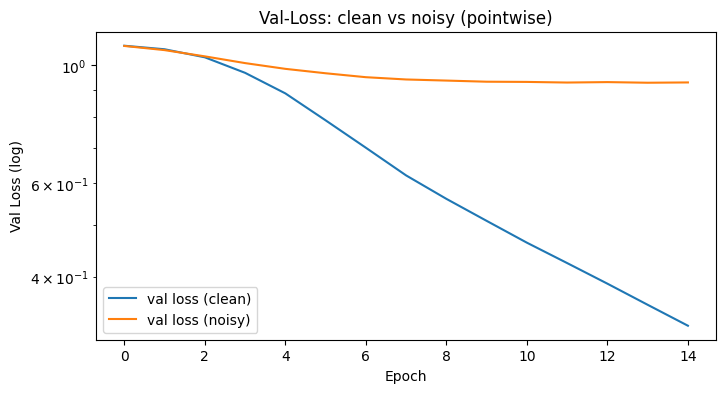

In [13]:
plt.figure(figsize=(8,4))
plt.plot(hist['val_loss'], label='val loss (clean)')
plt.plot(hist_n['val_loss'], label='val loss (noisy)')
plt.yscale('log'); plt.xlabel('Epoch'); plt.ylabel('Val Loss (log)'); plt.legend(); plt.title('Val-Loss: clean vs noisy (pointwise)')


Test (noisy): loss= 0.9176597419314915  acc= 0.5493333333333333
Confusion matrix (noisy):
 [[500 170  60]
 [263 269 208]
 [ 94 219 467]]


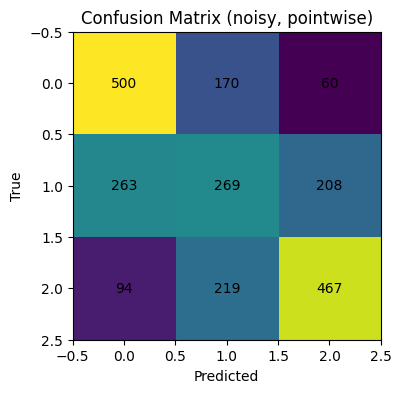

In [14]:
te_loss_n, te_acc_n, te_probs_n, te_true_n, te_pred_n = eval_pointwise(model_n, test_loader_n, crit_n, device)
print('Test (noisy): loss=', te_loss_n, ' acc=', te_acc_n)
cm_n = confusion_matrix(te_true_n, te_pred_n)
print('Confusion matrix (noisy):\n', cm_n)
plt.figure(figsize=(5,4))
plt.imshow(cm_n)
plt.title('Confusion Matrix (noisy, pointwise)')
plt.xlabel('Predicted'); plt.ylabel('True')
for i in range(cm_n.shape[0]):
    for j in range(cm_n.shape[1]):
        plt.text(j, i, cm_n[i,j], ha='center', va='center')


In [15]:
acc_n = accuracy_score(te_true_n, te_pred_n)
prec_n = precision_score(te_true_n, te_pred_n, average='macro', zero_division=0)
rec_n = recall_score(te_true_n, te_pred_n, average='macro', zero_division=0)
f1_n = f1_score(te_true_n, te_pred_n, average='macro', zero_division=0)
print(f'[noisy] Accuracy={acc_n:.3f} | Precision={prec_n:.3f} | Recall={rec_n:.3f} | F1={f1_n:.3f}')


[noisy] Accuracy=0.549 | Precision=0.543 | Recall=0.549 | F1=0.544


ROC-AUC (macro, OvO, noisy): 0.7349233140460326


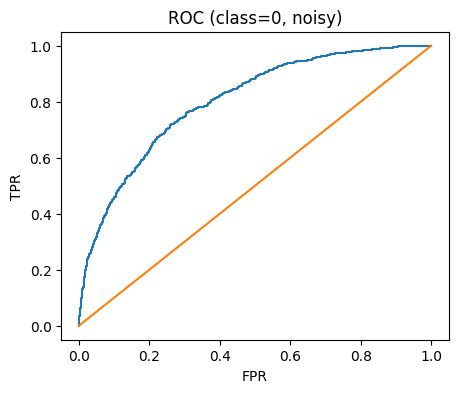

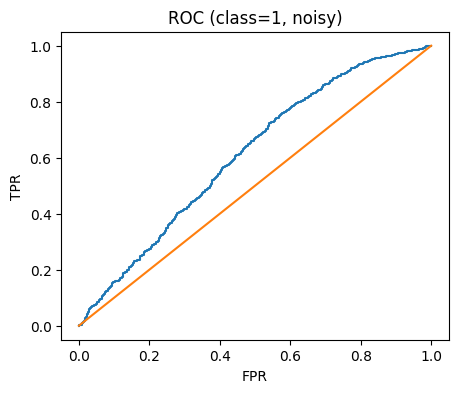

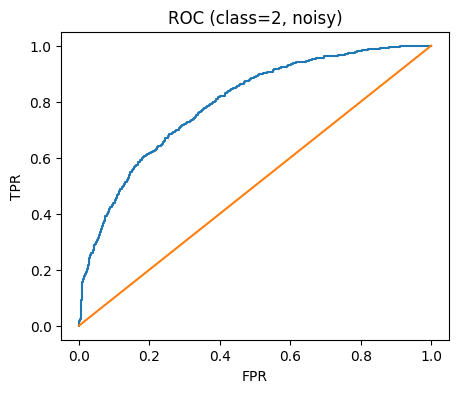

In [16]:
try:
    y_true_ovr_n = np.eye(3)[te_true_n]
    roc_auc_n = roc_auc_score(y_true_ovr_n, te_probs_n, average='macro', multi_class='ovo')
    print('ROC-AUC (macro, OvO, noisy):', roc_auc_n)
    for k in range(3):
        fpr, tpr, _ = roc_curve((te_true_n==k).astype(int), te_probs_n[:,k])
        plt.figure(figsize=(5,4))
        plt.plot(fpr, tpr)
        plt.plot([0,1],[0,1])
        plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title(f'ROC (class={k}, noisy)')
except Exception as e:
    print('ROC computation failed (noisy):', e)


Text(0.5, 1.0, 'Calibration (noisy, class=1)')

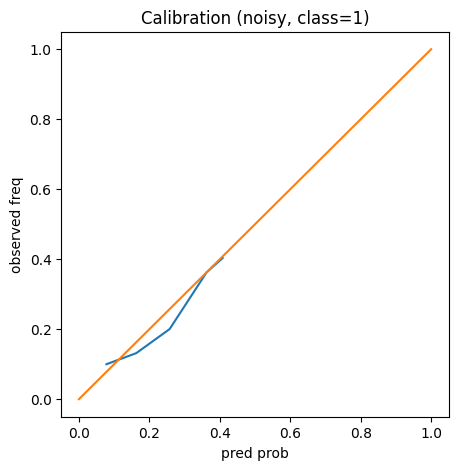

In [17]:
prob_true_n, prob_pred_n = calibration_curve((te_true_n==1).astype(int), te_probs_n[:,1], n_bins=10)
plt.figure(figsize=(5,5))
plt.plot(prob_pred_n, prob_true_n)
plt.plot([0,1],[0,1])
plt.xlabel('pred prob'); plt.ylabel('observed freq'); plt.title('Calibration (noisy, class=1)')


## Sensitivity‑Heatmap `P(hit)` über `(theta, v0)` (clean vs. noisy Modelle)

Text(0.5, 1.0, 'Sensitivity: P(hit) noisy')

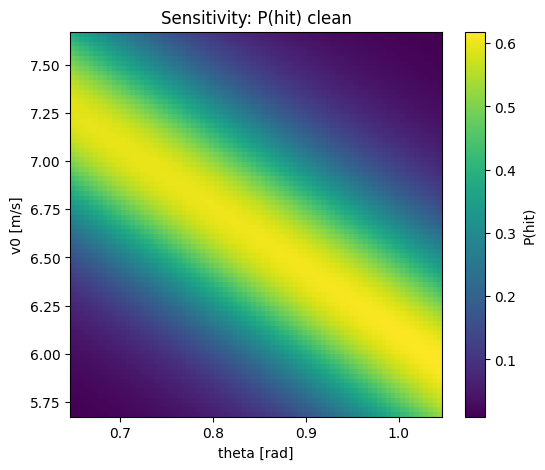

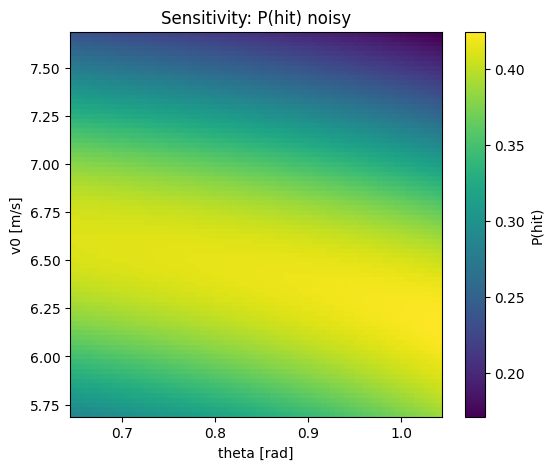

In [18]:
def sensitivity_heatmap(model, theta_mean, v0_mean, hs=2.13, grid=80):
    thetas = np.linspace(theta_mean-0.2, theta_mean+0.2, grid)
    v0s = np.linspace(v0_mean-1.0, v0_mean+1.0, grid)
    TT, VV = np.meshgrid(thetas, v0s)
    l = 4.115
    # Zeit am Korb (x=l): t = l / (v0 cos theta)
    t_for_x = l / (VV*np.cos(TT))
    hs_arr = np.full_like(t_for_x, hs)
    X = np.stack([TT.flatten(), VV.flatten(), hs_arr.flatten(), t_for_x.flatten()], axis=1).astype(np.float32)
    X_seq = X.reshape(-1,1,4)
    with torch.no_grad():
        logits = model(torch.tensor(X_seq, dtype=torch.float32))
        probs = torch.softmax(logits, dim=1).cpu().numpy()[:,1]
    Z = probs.reshape(grid, grid)
    return thetas, v0s, Z

theta_mean = float(dproc['theta'].mean())
v0_mean = float(dproc['v0'].mean())
th, v0g, Z_clean = sensitivity_heatmap(model, theta_mean, v0_mean)
th2, v0g2, Z_noisy = sensitivity_heatmap(model_n, float(dproc_n['theta'].mean()), float(dproc_n['v0'].mean()))

plt.figure(figsize=(6,5))
plt.imshow(Z_clean, extent=(th.min(), th.max(), v0g.min(), v0g.max()), origin='lower', aspect='auto')
plt.colorbar(label='P(hit)'); plt.xlabel('theta [rad]'); plt.ylabel('v0 [m/s]'); plt.title('Sensitivity: P(hit) clean')

plt.figure(figsize=(6,5))
plt.imshow(Z_noisy, extent=(th2.min(), th2.max(), v0g2.min(), v0g2.max()), origin='lower', aspect='auto')
plt.colorbar(label='P(hit)'); plt.xlabel('theta [rad]'); plt.ylabel('v0 [m/s]'); plt.title('Sensitivity: P(hit) noisy')


In [19]:
comp = pd.DataFrame([
    {'set':'clean','acc':accuracy_score(te_true, te_pred),'prec':precision_score(te_true, te_pred, average='macro', zero_division=0),'rec':recall_score(te_true, te_pred, average='macro', zero_division=0),'f1':f1_score(te_true, te_pred, average='macro', zero_division=0)},
    {'set':'noisy','acc':accuracy_score(te_true_n, te_pred_n),'prec':precision_score(te_true_n, te_pred_n, average='macro', zero_division=0),'rec':recall_score(te_true_n, te_pred_n, average='macro', zero_division=0),'f1':f1_score(te_true_n, te_pred_n, average='macro', zero_division=0)},
])
print(comp)


     set       acc     prec       rec        f1
0  clean  1.000000  1.00000  1.000000  1.000000
1  noisy  0.549333  0.54254  0.549054  0.543819
